# HydrAI — Train & Evaluate Tree Surrogates (Inlet→Outlet)

**Combined workflow:** Train RF, Gradient Boosting, XGBoost, AdaBoost on PFR exit-plane data, evaluate on held-out test set, and compare models.

**Prerequisites:** Run Main_2 and Main_3 so `data/processed/features_targets_*.pkl` exists.

---

## Overfitting Control Strategy

Overfitting occurs when a model memorises training data but fails to generalise. This notebook employs:

1. **Train/Test Split** (80/20): Model never sees test data during training — final metrics reflect real-world performance.
2. **Cross-Validation** (CV=3–5): During hyperparameter tuning, each candidate is validated on multiple folds to detect overfitting early.
3. **Regularisation Parameters**:
   - `max_depth`: limits tree depth (prevents memorising noise)
   - `min_samples_split`, `min_samples_leaf`: requires minimum samples to split/form leaves
   - XGBoost: `reg_alpha` (L1), `reg_lambda` (L2), `gamma` (min loss reduction)
4. **Early Stopping** (XGBoost): optional, stops adding trees when validation score plateaus.
5. **Ensemble Averaging**: tree ensembles (RF, GB) inherently reduce variance vs single trees.

**Key diagnostic:** Compare **Train R²** vs **Test R²**. A large gap (e.g., Train=0.999, Test=0.90) signals overfitting → increase regularisation or gather more data.

---

**Sections:**
1. Setup & imports
2. Paths & flags
3. Load data
4. Features & targets (exit-plane)
5. Train/test split & scaling
6. Train models
7. Hyperparameter tuning (optional)
8. Test-set evaluation & model comparison
9. Actual vs Predicted scatter plots (state variables)
10. Species chemistry analysis (lumped groups)
11. Export models

In [60]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1. SETUP & IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════
import os
import sys
import glob
import json
import joblib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    max_error,
)
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import randint, uniform

# Project root
current_dir = Path(os.getcwd())
project_root = current_dir if (current_dir / "src").exists() else current_dir.parent
sys.path.insert(0, str(project_root))
os.chdir(project_root)

from src.utils.plot_style import setup_matplotlib
from src.ml.dataframe_pickle import load_portable_pickle

setup_matplotlib()
print("Libraries imported successfully.")

Libraries imported successfully.


In [61]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2. PATHS & FLAGS
# ═══════════════════════════════════════════════════════════════════════════════

# I/O flags
IF_PLOT_SHOWN        = True
IF_PLOT_EXPORT       = True
IF_MODEL_EXPORT      = True

# Which models to train (None = all four; or list e.g. ['random_forest', 'xgboost'])
# Note: 'adaboost' is slow on 300+ targets — remove for fast iteration
MODELS_TO_TRAIN = ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']

# Hyperparameter tuning
IF_HYPERPARAM_TUNING = False
TUNING_N_ITER        = 20    # number of random search iterations
TUNING_CV            = 3     # cross-validation folds
TUNING_SCORING       = 'neg_mean_absolute_error'

# Paths
CONFIG_PATH        = project_root / "configs" / "ml" / "ml_training_config.json"
PROCESSED_DATA_DIR = project_root / "data" / "processed"
EXPORT_DIR         = project_root / "models"
FIG_DIR            = project_root / "outputs" / "figures" / "Main_4_train_and_evaluate"

print(f"Plot: {IF_PLOT_SHOWN}  |  Export figs: {IF_PLOT_EXPORT}  |  Export models: {IF_MODEL_EXPORT}")
print(f"Tuning: {IF_HYPERPARAM_TUNING}  |  N_ITER={TUNING_N_ITER}  |  CV={TUNING_CV}")
print(f"Models to train: {MODELS_TO_TRAIN if MODELS_TO_TRAIN else 'all'}")

Plot: True  |  Export figs: True  |  Export models: True
Tuning: False  |  N_ITER=20  |  CV=3
Models to train: ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']


In [62]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. LOAD CONFIG & DATA
# ═══════════════════════════════════════════════════════════════════════════════

# Config
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        config = json.load(f)
else:
    config = {}
    print(f"[WARN] Config not found: {CONFIG_PATH}. Using defaults.")

TEST_SIZE    = config.get("test_size", 0.2)
RANDOM_STATE = config.get("random_state", 42)
RF_CONFIG    = config.get("random_forest", {"n_estimators": 100, "max_depth": 20})
GB_CONFIG    = config.get("gradient_boosting", {"n_estimators": 150, "max_depth": 5})
XGB_CONFIG   = config.get("xgboost", {"n_estimators": 150, "max_depth": 6})
ADA_CONFIG   = config.get("adaboost", {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 6})

print(f"Config: test_size={TEST_SIZE}, random_state={RANDOM_STATE}")

# Data (latest features_targets_*.pkl)
pkl_files = sorted(glob.glob(str(PROCESSED_DATA_DIR / "features_targets_*.pkl")), reverse=True)
if not pkl_files:
    raise FileNotFoundError(f"No features_targets_*.pkl in {PROCESSED_DATA_DIR}. Run Main_3 first.")

DATA_FILE = pkl_files[0]
loaded = load_portable_pickle(DATA_FILE)
df_features = loaded["df_features"]
df_target = loaded["df_target"]

print(f"Data: {Path(DATA_FILE).name}")
print(f"  Features: {df_features.shape[0]:,} rows × {df_features.shape[1]} cols")
print(f"  Targets:  {df_target.shape[0]:,} rows × {df_target.shape[1]} cols")

Config: test_size=0.2, random_state=42
Data: features_targets_training_data_complete_20260507_111316.pkl
  Features: 2,006 rows × 8 cols
  Targets:  2,006 rows × 319 cols


In [63]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. FEATURES & TARGETS (EXIT-PLANE ONLY)
# ═══════════════════════════════════════════════════════════════════════════════
# For inlet→outlet prediction, we keep only one row per simulation run:
# the row at maximum relative_position (reactor exit).
import re

feature_cols = [
    "initial_temperature_K", "initial_pressure_Pa",
    "reactor_length_m", "reactor_diameter_m",
    "mass_flow_rate_kgps", "heat_flux_Wm2",
    "z_position_m", "relative_position",
]
if "reactant_type" in df_features.columns:
    feature_cols.append("reactant_type")
feature_cols = [c for c in feature_cols if c in df_features.columns]

# Run-identifying columns (exclude spatial coords)
run_cols = [c for c in feature_cols if c not in ("z_position_m", "relative_position")]

# Primary targets (state + thermo)
primary_targets = [
    "temperature_K", "pressure_Pa", "velocity_ms", "density_kgm3",
    "mean_molecular_weight_kgkmol", "heat_capacity_cp_JkgK", "heat_capacity_cv_JkgK",
    "enthalpy_Jkg", "thermal_conductivity_WmK",
]
state_target_cols = [c for c in primary_targets if c in df_target.columns]

# Species targets: mass fractions only — individual Y_* or Y_lump_* from Main_3
_lump_cols = [c for c in df_target.columns if c.startswith('Y_lump_')]
if _lump_cols:
    species_cols = sorted(_lump_cols)
else:
    species_cols = [c for c in df_target.columns if c.startswith('Y_')]

# All targets for training
target_cols = state_target_cols + species_cols

# ═══════════════════════════════════════════════════════════════════════════════
# Chemistry grouping for plots: Y_lump_chem_* / Y_lump_carbon_* map 1:1; else classify Y_*
# ═══════════════════════════════════════════════════════════════════════════════
def classify_species_chemistry(species_name):
    """Classify species by chemical role."""
    name = species_name[2:] if species_name.startswith('Y_') else species_name
    name_base = name.split('(')[0]
    
    if name_base == 'H2':
        return 'hydrogen'
    if name_base in {'Water', 'Ar', 'He', 'Ne', 'N2', 'H'}:
        return 'diluent'
    if name_base == 'C6H14':
        return 'feedstock'
    if name_base in {'C2H4', 'C3H6', 'C4H6', 'C4H8'}:
        return 'olefins'
    if name_base in {'Benzene', 'Toluene', 'Styrene', 'C8H10'}:
        return 'aromatics'
    if name_base in {'CH4', 'CC', 'CCC'}:
        return 'paraffins'
    if name_base.startswith('C#C') or name_base == 'C2H2':
        return 'coke_precursors'
    if name_base in {'C5H6', 'C5H5', 'C3H4', 'C4H4', 'C4H5'}:
        return 'coke_precursors'
    # Highly unsaturated C6+
    match = re.match(r'^C(\d+)H(\d+)', name_base)
    if match:
        c, h = int(match.group(1)), int(match.group(2))
        if c >= 6 and h / c < 1.5:
            return 'coke_precursors'
    # Radicals
    if name_base in {'CH3', 'C2H3', 'C2H5', 'C3H5', 'C3H7', 'C4H7', 'C4H9', 
                     'C5H7', 'C5H9', 'C5H11', 'C6H7', 'C6H9', 'C6H11', 'C6H13',
                     'C7H9', 'C7H11', 'C3H3'}:
        return 'radicals'
    return 'other'

chemistry_groups = {}
if species_cols and all(c.startswith('Y_lump_chem_') for c in species_cols):
    for c in species_cols:
        role = c[len('Y_lump_chem_'):]
        chemistry_groups[role] = [c]
elif species_cols and all(c.startswith('Y_lump_carbon_') for c in species_cols):
    for c in species_cols:
        suf = c[len('Y_lump_carbon_'):]
        chemistry_groups[f'carbon_{suf}'] = [c]
else:
    for col in species_cols:
        role = classify_species_chemistry(col)
        chemistry_groups.setdefault(role, []).append(col)

print("Species / lump columns by chemistry role:")
for role, cols in sorted(chemistry_groups.items()):
    print(f"  {role}: {len(cols)} column(s)")

# Extract exit-plane rows (max relative_position per run)
exit_idx = df_features.groupby(run_cols, dropna=False)["relative_position"].idxmax().values
X_exit = df_features.loc[exit_idx, feature_cols].copy()
y_exit = df_target.loc[exit_idx, target_cols].copy()

# Encode categorical (reactant_type)
label_encoder = None
if "reactant_type" in X_exit.columns:
    label_encoder = LabelEncoder()
    X_exit["reactant_type"] = label_encoder.fit_transform(X_exit["reactant_type"].astype(str))

print(f"\nExit-plane dataset: {len(X_exit):,} samples")
print(f"  Input features ({len(feature_cols)}): {feature_cols}")
print(f"  State targets ({len(state_target_cols)}): {state_target_cols}")
print(f"  Species / lump targets: {len(species_cols)} columns")

Species grouped by chemistry:
  aromatics: 4 species
  coke_precursors: 71 species
  diluent: 7 species
  feedstock: 1 species
  olefins: 11 species
  other: 10 species
  paraffins: 3 species
  radicals: 46 species

Exit-plane dataset: 10 samples
  Input features (8): ['initial_temperature_K', 'initial_pressure_Pa', 'reactor_length_m', 'reactor_diameter_m', 'mass_flow_rate_kgps', 'heat_flux_Wm2', 'z_position_m', 'relative_position']
  State targets (9): ['temperature_K', 'pressure_Pa', 'velocity_ms', 'density_kgm3', 'mean_molecular_weight_kgkmol', 'heat_capacity_cp_JkgK', 'heat_capacity_cv_JkgK', 'enthalpy_Jkg', 'thermal_conductivity_WmK']
  Species targets: 153 (Y_* columns)


In [64]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5. TRAIN/TEST SPLIT & SCALING
# ═══════════════════════════════════════════════════════════════════════════════
# 80/20 split ensures models are evaluated on unseen data.
# StandardScaler normalises features (mean=0, std=1) — fitted on train only.

X_train, X_test, y_train, y_test = train_test_split(
    X_exit, y_exit, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {len(X_train):,} ({100*(1-TEST_SIZE):.0f}%)  |  Test: {len(X_test):,} ({100*TEST_SIZE:.0f}%)")
print(f"Targets: {len(target_cols)}")

Train: 8 (80%)  |  Test: 2 (20%)
Targets: 162


In [65]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6. TRAIN MODELS (DEFAULT PARAMS)
# ═══════════════════════════════════════════════════════════════════════════════
ALL_MODEL_KEYS = ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']
keys_to_train = ALL_MODEL_KEYS if MODELS_TO_TRAIN is None else MODELS_TO_TRAIN

models = {}

if 'random_forest' in keys_to_train:
    print("Training Random Forest...")
    base_rf = RandomForestRegressor(
        n_estimators=RF_CONFIG.get("n_estimators", 100),
        max_depth=RF_CONFIG.get("max_depth", 20),
        min_samples_leaf=RF_CONFIG.get("min_samples_leaf", 1),
        random_state=RANDOM_STATE, n_jobs=1
    )
    models['random_forest'] = MultiOutputRegressor(base_rf, n_jobs=-1).fit(X_train_s, y_train)
    print("  Random Forest done.")

if 'gradient_boosting' in keys_to_train:
    print("Training Gradient Boosting...")
    base_gb = GradientBoostingRegressor(
        n_estimators=GB_CONFIG.get("n_estimators", 150),
        max_depth=GB_CONFIG.get("max_depth", 5),
        min_samples_leaf=GB_CONFIG.get("min_samples_leaf", 1),
        random_state=RANDOM_STATE
    )
    models['gradient_boosting'] = MultiOutputRegressor(base_gb, n_jobs=-1).fit(X_train_s, y_train)
    print("  Gradient Boosting done.")

if 'xgboost' in keys_to_train:
    print("Training XGBoost...")
    base_xgb = xgb.XGBRegressor(
        n_estimators=XGB_CONFIG.get("n_estimators", 150),
        max_depth=XGB_CONFIG.get("max_depth", 6),
        learning_rate=XGB_CONFIG.get("learning_rate", 0.1),
        reg_alpha=XGB_CONFIG.get("reg_alpha", 0),
        reg_lambda=XGB_CONFIG.get("reg_lambda", 1),
        random_state=RANDOM_STATE, n_jobs=1
    )
    models['xgboost'] = MultiOutputRegressor(base_xgb, n_jobs=-1).fit(X_train_s, y_train)
    print("  XGBoost done.")

if 'adaboost' in keys_to_train:
    print("Training AdaBoost (slow on many targets)...")
    base_ada = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(
            max_depth=ADA_CONFIG.get("max_depth", 6),
            random_state=RANDOM_STATE
        ),
        n_estimators=ADA_CONFIG.get("n_estimators", 200),
        learning_rate=ADA_CONFIG.get("learning_rate", 0.1),
        random_state=RANDOM_STATE
    )
    models['adaboost'] = MultiOutputRegressor(base_ada, n_jobs=-1).fit(X_train_s, y_train)
    print("  AdaBoost done.")

print(f"\nTrained models: {list(models.keys())}")

Training Random Forest...


  Random Forest done.
Training Gradient Boosting...
  Gradient Boosting done.
Training XGBoost...
  XGBoost done.
Training AdaBoost (slow on many targets)...
  AdaBoost done.

Trained models: ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']


In [66]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7. HYPERPARAMETER TUNING (OPTIONAL)
# ═══════════════════════════════════════════════════════════════════════════════
# RandomizedSearchCV with cross-validation finds good hyperparameters while
# avoiding overfitting (CV score penalises models that don't generalise).

if IF_HYPERPARAM_TUNING:
    print("=" * 60)
    print("HYPERPARAMETER TUNING (RandomizedSearchCV)")
    print(f"  N_ITER={TUNING_N_ITER}, CV={TUNING_CV}, scoring={TUNING_SCORING}")
    print("=" * 60)

    param_distributions = {
        'random_forest': {
            'estimator__n_estimators': randint(100, 301),
            'estimator__max_depth': [10, 15, 20, 25, None],
            'estimator__min_samples_split': randint(2, 11),
            'estimator__min_samples_leaf': randint(1, 5),
        },
        'gradient_boosting': {
            'estimator__n_estimators': randint(100, 301),
            'estimator__learning_rate': [0.01, 0.05, 0.1],
            'estimator__max_depth': randint(3, 7),
            'estimator__min_samples_leaf': randint(1, 5),
            'estimator__subsample': uniform(0.7, 0.3),
        },
        'xgboost': {
            'estimator__n_estimators': randint(100, 401),
            'estimator__max_depth': randint(3, 8),
            'estimator__learning_rate': [0.01, 0.05, 0.1],
            'estimator__subsample': uniform(0.7, 0.3),
            'estimator__colsample_bytree': uniform(0.7, 0.3),
            'estimator__reg_alpha': [0, 0.01, 0.1],
            'estimator__reg_lambda': [1, 2, 5],
        },
        'adaboost': {
            'estimator__n_estimators': randint(100, 301),
            'estimator__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'estimator__estimator__max_depth': randint(3, 8),
        },
    }

    def build_base(key):
        if key == 'random_forest':
            return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
        if key == 'gradient_boosting':
            return GradientBoostingRegressor(random_state=RANDOM_STATE)
        if key == 'xgboost':
            return xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=1)
        if key == 'adaboost':
            return AdaBoostRegressor(
                estimator=DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
                random_state=RANDOM_STATE
            )

    for key in models.keys():
        if key not in param_distributions:
            continue
        print(f"\n  Tuning {key}...")
        pipe = MultiOutputRegressor(build_base(key), n_jobs=-1)
        search = RandomizedSearchCV(
            pipe, param_distributions[key],
            n_iter=TUNING_N_ITER, cv=TUNING_CV,
            scoring=TUNING_SCORING, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
        )
        search.fit(X_train_s, y_train)
        score = -search.best_score_ if TUNING_SCORING.startswith('neg_') else search.best_score_
        print(f"    Best CV score: {score:.4f}")
        print(f"    Best params: {search.best_params_}")
        models[key] = search.best_estimator_

    print("\nTuning complete. Models updated with best estimators.")
else:
    print("Hyperparameter tuning disabled.")

Hyperparameter tuning disabled.


In [67]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8. TEST-SET EVALUATION & MODEL COMPARISON
# ═══════════════════════════════════════════════════════════════════════════════
# Key metrics:
#   R² — explained variance (1.0 = perfect, <0 = worse than mean)
#   MAE — mean absolute error (interpretable units)
#   RMSE — root mean squared error (penalises large errors)
#   MAPE% — mean absolute percentage error (scale-independent)
#   MBE — mean bias error (positive = overprediction)
#
# Overfitting check: Train R² >> Test R² indicates overfitting.

DISPLAY_NAMES = {
    'random_forest': 'Random Forest',
    'gradient_boosting': 'Gradient Boosting',
    'xgboost': 'XGBoost',
    'adaboost': 'AdaBoost',
}

def compute_metrics(y_true, y_pred, target_names):
    """Compute per-target metrics."""
    rows = []
    for i, tgt in enumerate(target_names):
        yt = y_true[:, i] if y_true.ndim > 1 else y_true
        yp = y_pred[:, i] if y_pred.ndim > 1 else y_pred
        mask = np.abs(yt) > 1e-12
        mape = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100 if mask.any() else np.nan
        rows.append({
            'target': tgt,
            'R2': r2_score(yt, yp),
            'MAE': mean_absolute_error(yt, yp),
            'RMSE': np.sqrt(mean_squared_error(yt, yp)),
            'MAPE_%': mape,
            'MBE': np.mean(yp - yt),
        })
    return pd.DataFrame(rows)

# Compute metrics for each model
results = []
for key, model in models.items():
    # Train metrics (for overfitting check)
    y_train_pred = model.predict(X_train_s)
    train_r2 = r2_score(y_train, y_train_pred, multioutput='uniform_average')
    
    # Test metrics
    y_test_pred = model.predict(X_test_s)
    test_r2 = r2_score(y_test, y_test_pred, multioutput='uniform_average')
    test_mae = mean_absolute_error(y_test, y_test_pred, multioutput='uniform_average')
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred, multioutput='uniform_average'))
    
    # Per-target MAPE
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
    mask = np.abs(y_test_np) > 1e-12
    mape_per_target = np.abs((y_test_np - y_test_pred) / np.where(mask, y_test_np, 1)) * 100
    mape_per_target = np.where(mask, mape_per_target, np.nan)
    test_mape = np.nanmean(mape_per_target)
    
    results.append({
        'Model': DISPLAY_NAMES.get(key, key),
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Test_MAE': test_mae,
        'Test_RMSE': test_rmse,
        'Test_MAPE_%': test_mape,
        'Overfit_Gap': train_r2 - test_r2,
    })

df_results = pd.DataFrame(results).sort_values('Test_R2', ascending=False)

print("=" * 80)
print("MODEL COMPARISON — Test Set Evaluation")
print("=" * 80)
print(df_results.to_string(index=False))
print()
print("Key: Overfit_Gap = Train_R² - Test_R² (large gap > 0.05 suggests overfitting)")
print("=" * 80)

MODEL COMPARISON — Test Set Evaluation
            Model  Train_R2       Test_R2    Test_MAE    Test_RMSE  Test_MAPE_%  Overfit_Gap
          XGBoost  0.218059 -1.994567e+01 3340.469971 54782.077069 2.812230e+06 2.016373e+01
    Random Forest  0.369300 -1.359284e+07 6099.380580 75940.538084 3.669628e+07 1.359284e+07
         AdaBoost  0.429050 -1.532908e+07 4459.171473 61147.194526 2.642672e+06 1.532908e+07
Gradient Boosting  0.457147 -1.538108e+07 5212.733197 67521.205601 1.790076e+07 1.538108e+07

Key: Overfit_Gap = Train_R² - Test_R² (large gap > 0.05 suggests overfitting)


In [68]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8b. PER-TARGET METRICS TABLE
# ═══════════════════════════════════════════════════════════════════════════════
# Detailed breakdown per target variable.

per_target_rows = []
for key, model in models.items():
    y_pred = model.predict(X_test_s)
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
    for i, tgt in enumerate(target_cols):
        yt = y_test_np[:, i]
        yp = y_pred[:, i]
        mask = np.abs(yt) > 1e-12
        mape = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100 if mask.any() else np.nan
        per_target_rows.append({
            'Model': DISPLAY_NAMES.get(key, key),
            'Target': tgt,
            'R2': r2_score(yt, yp),
            'MAE': mean_absolute_error(yt, yp),
            'RMSE': np.sqrt(mean_squared_error(yt, yp)),
            'MAPE_%': mape,
        })

df_per_target = pd.DataFrame(per_target_rows)

# Pivot for comparison
print("\nPer-target R² (Test Set):")
print("-" * 60)
pivot_r2 = df_per_target.pivot(index='Target', columns='Model', values='R2')
print(pivot_r2.round(4).to_string())


Per-target R² (Test Set):
------------------------------------------------------------
Model                             AdaBoost  Gradient Boosting  Random Forest       XGBoost
Target                                                                                    
Y_Ar                         -1.489982e+04      -1.847853e+04  -1.799424e+04 -1.847853e+04
Y_Benzene(2)                 -2.220000e-01      -2.000300e+00  -8.250000e-01 -9.772100e+00
Y_C#C(421)                   -2.908000e-01      -3.360000e-01   3.525000e-01  6.490000e-02
Y_C#CC(563)                   1.821000e-01       4.479000e-01   2.942000e-01  5.049000e-01
Y_C#CCC(445)                 -3.164990e+01      -2.566081e+02  -1.496476e+02 -1.464052e+02
Y_C2H2(431)                  -8.530000e-01      -4.776760e+01  -2.194300e+01 -6.235200e+00
Y_C2H3(26)                   -8.420000e-02      -8.111500e+00  -1.592200e+00 -4.253000e-01
Y_C2H4(8)                    -5.479400e+00      -5.744000e-01   3.072000e-01  1.247000e-01
Y_

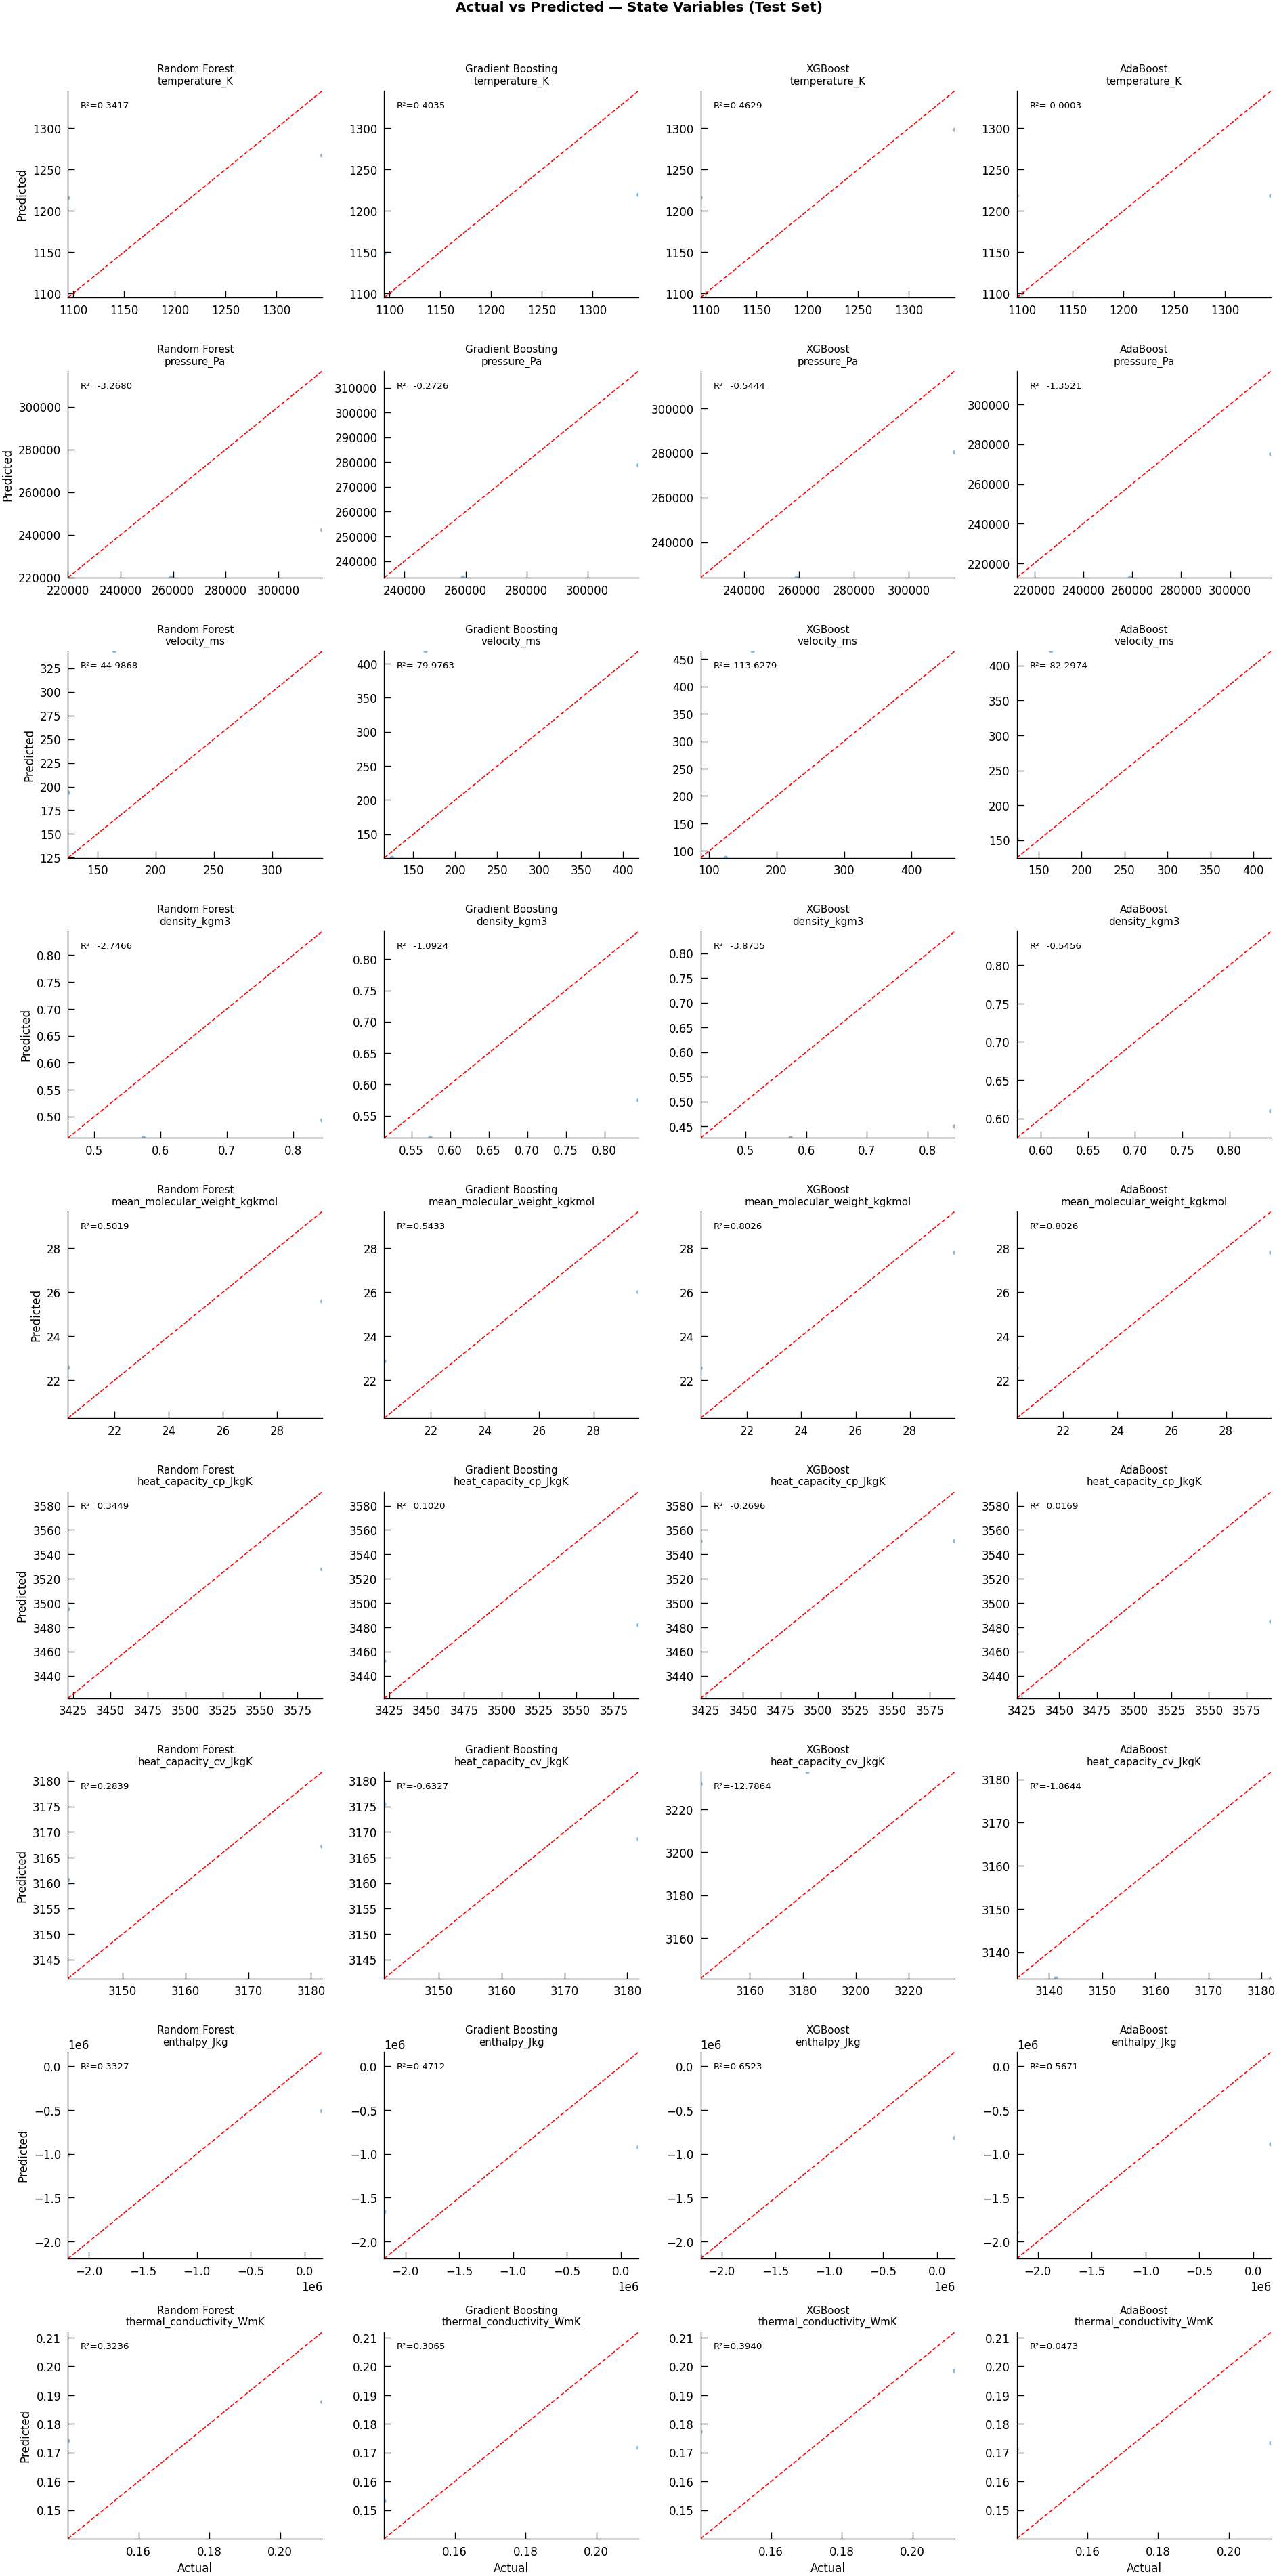

In [69]:
# ═══════════════════════════════════════════════════════════════════════════════
# 9. ACTUAL VS PREDICTED — SCATTER PLOTS (STATE VARIABLES ONLY)
# ═══════════════════════════════════════════════════════════════════════════════
# Perfect predictions lie on y=x diagonal. Spread around diagonal = error.
# Only plotting state targets here; species are analyzed in chemistry section.

# Only state variables for scatter plots (species handled in chemistry section)
scatter_targets = state_target_cols
n_scatter = len(scatter_targets)
n_models = len(models)

if n_scatter > 0 and n_models > 0:
    fig, axes = plt.subplots(n_scatter, n_models, figsize=(4 * n_models, 3.5 * n_scatter), squeeze=False)
    
    for j, (key, model) in enumerate(models.items()):
        y_pred = model.predict(X_test_s)
        y_test_np = y_test.values if hasattr(y_test, 'values') else y_test
        
        for i, tgt in enumerate(scatter_targets):
            ax = axes[i, j]
            tgt_idx = target_cols.index(tgt)
            yt = y_test_np[:, tgt_idx]
            yp = y_pred[:, tgt_idx]
            
            ax.scatter(yt, yp, alpha=0.5, s=15, edgecolors='none')
            lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
            ax.plot(lims, lims, 'r--', lw=1, label='y=x')
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            
            r2 = r2_score(yt, yp)
            ax.set_title(f"{DISPLAY_NAMES.get(key, key)}\n{tgt}", fontsize=9)
            ax.text(0.05, 0.95, f"R²={r2:.4f}", transform=ax.transAxes, fontsize=8, va='top')
            
            if i == n_scatter - 1:
                ax.set_xlabel('Actual')
            if j == 0:
                ax.set_ylabel('Predicted')
    
    plt.suptitle('Actual vs Predicted — State Variables (Test Set)', fontweight='bold', y=1.01)
    plt.tight_layout()
    
    if IF_PLOT_EXPORT:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / 'actual_vs_predicted_state_scatter.png', dpi=150, bbox_inches='tight')
    if IF_PLOT_SHOWN:
        plt.show()
    plt.close(fig)
else:
    print("No state targets or models to plot.")

Using best model for species analysis: XGBoost


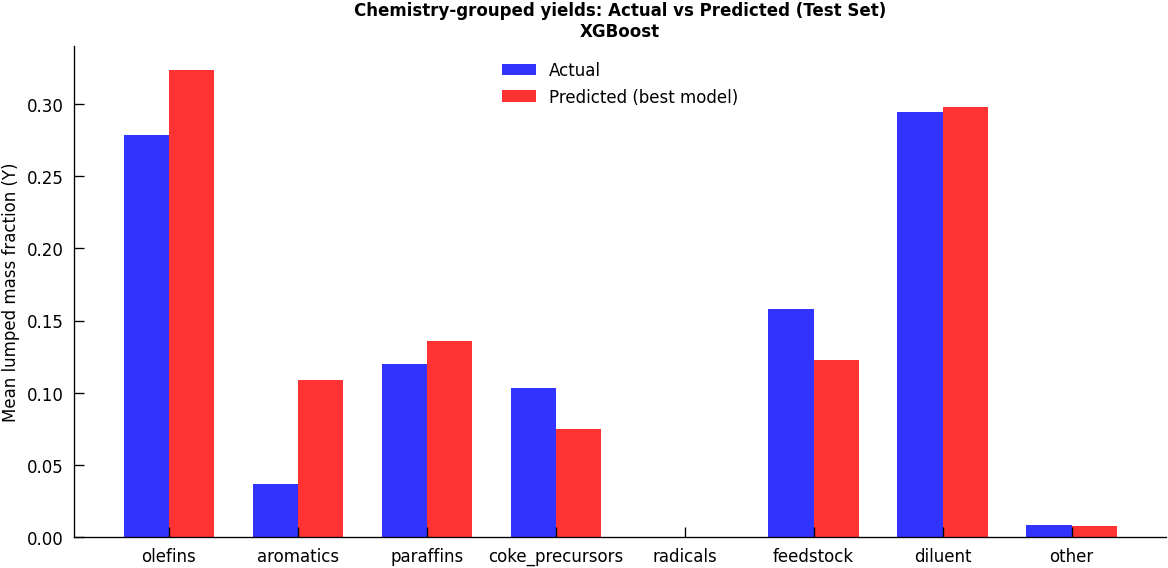

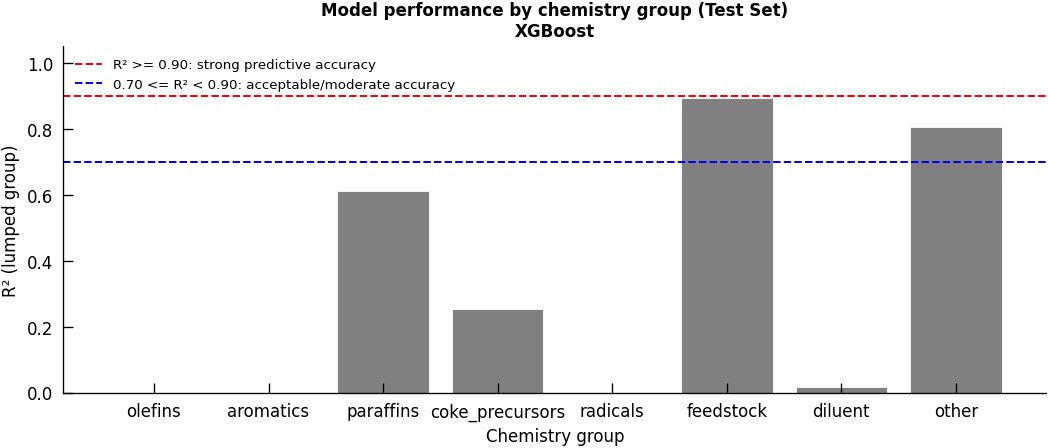

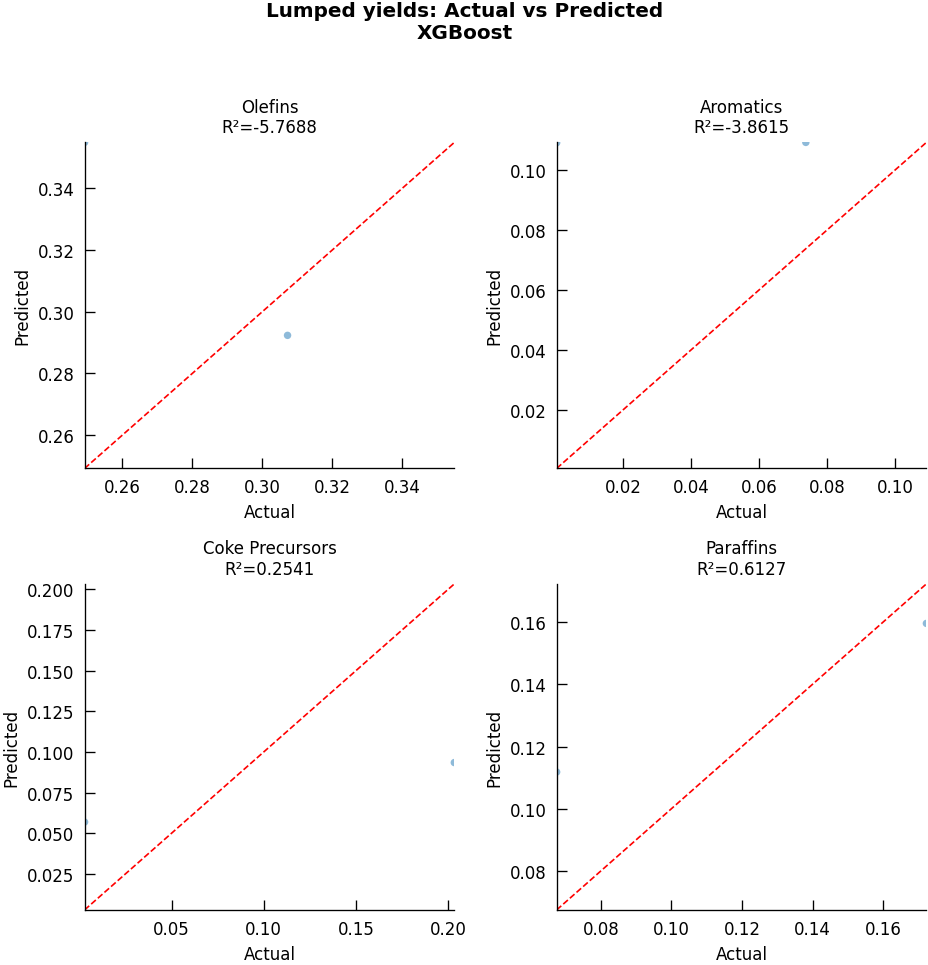


CHEMISTRY GROUP PERFORMANCE (lumped mass fractions)
          Group  N_species  Actual_Y  Predicted_Y    Error_%         R2
        olefins         11  0.278191     0.323566  16.310844  -5.768811
      aromatics          4  0.037060     0.109200 194.654986  -3.861542
      paraffins          3  0.119875     0.135687  13.190558   0.612720
coke_precursors         71  0.103130     0.075200 -27.082542   0.254118
       radicals         46  0.000168     0.000403 140.350092 -66.813727
      feedstock          1  0.158102     0.123014 -22.193680   0.893025
        diluent          7  0.294669     0.297566   0.982999   0.017119
          other         10  0.008806     0.007549 -14.277778   0.806451


In [70]:
# ═══════════════════════════════════════════════════════════════════════════════
# 10. SPECIES CHEMISTRY ANALYSIS (LUMPED GROUPS)
# ═══════════════════════════════════════════════════════════════════════════════
# Analyze model performance on chemistry-grouped species.
# Groups: olefins (primary products), aromatics (BTX), paraffins, coke_precursors, radicals, etc.

# Use the best model for species analysis
best_model_key = df_results.iloc[0]['Model'].lower().replace(' ', '_')
if best_model_key not in models:
    best_model_key = list(models.keys())[0]
best_model = models[best_model_key]
print(f"Using best model for species analysis: {DISPLAY_NAMES.get(best_model_key, best_model_key)}")

# Get predictions
y_test_pred = best_model.predict(X_test_s)
y_test_np = y_test.values if hasattr(y_test, 'values') else y_test

# ── Plot 1: Lumped yields comparison (actual vs predicted) ──────────────────────
_default_chem_order = ['olefins', 'aromatics', 'paraffins', 'coke_precursors', 'radicals', 'feedstock', 'hydrogen', 'diluent', 'other']
if chemistry_groups and all(k in _default_chem_order for k in chemistry_groups.keys()):
    chemistry_order = [c for c in _default_chem_order if c in chemistry_groups]
else:
    chemistry_order = sorted(chemistry_groups.keys())

# Calculate lumped yields for each chemistry group
lumped_actual = {}
lumped_pred = {}
for role in chemistry_order:
    cols = chemistry_groups[role]
    col_idx = [target_cols.index(c) for c in cols if c in target_cols]
    if col_idx:
        lumped_actual[role] = y_test_np[:, col_idx].sum(axis=1).mean()
        lumped_pred[role] = y_test_pred[:, col_idx].sum(axis=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(lumped_actual))
width = 0.35
ax.bar(x - width/2, list(lumped_actual.values()), width, label='Actual', color='b', alpha=0.8)
ax.bar(x + width/2, list(lumped_pred.values()), width, label='Predicted (best model)', color='red', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(lumped_actual.keys()), rotation=0, ha='center')
ax.set_ylabel('Mean lumped mass fraction (Y)')
ax.set_title(f'Chemistry-grouped yields: Actual vs Predicted (Test Set)\n{DISPLAY_NAMES.get(best_model_key, best_model_key)}', fontweight='bold')
ax.legend()
plt.tight_layout()
if IF_PLOT_EXPORT:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / 'chemistry_lumped_yields_comparison.png', dpi=150, bbox_inches='tight')
if IF_PLOT_SHOWN:
    plt.show()
plt.close(fig)

# ── Plot 2: R² per chemistry group ──────────────────────────────────────────────
r2_by_group = {}
for role in chemistry_order:
    cols = chemistry_groups[role]
    col_idx = [target_cols.index(c) for c in cols if c in target_cols]
    if col_idx:
        yt = y_test_np[:, col_idx].sum(axis=1)
        yp = y_test_pred[:, col_idx].sum(axis=1)
        r2_by_group[role] = r2_score(yt, yp)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(r2_by_group.keys(), r2_by_group.values(), color='gray', edgecolor='white', linewidth=0.5)
ax.axhline(0.9, color='r', linestyle='--', alpha=1, label='R² >= 0.90: strong predictive accuracy')
ax.axhline(0.7, color='b', linestyle='--', alpha=1, label='0.70 <= R² < 0.90: acceptable/moderate accuracy')
ax.set_ylabel('R² (lumped group)')
ax.set_xlabel('Chemistry group')
ax.set_title(f'Model performance by chemistry group (Test Set)\n{DISPLAY_NAMES.get(best_model_key, best_model_key)}', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
if IF_PLOT_EXPORT:
    fig.savefig(FIG_DIR / 'chemistry_group_r2.png', dpi=150, bbox_inches='tight')
if IF_PLOT_SHOWN:
    plt.show()
plt.close(fig)

# ── Plot 3: Scatter plot — actual vs predicted for key groups ───────────────────
if chemistry_groups and all(str(k).startswith('carbon_') for k in chemistry_groups.keys()):
    key_groups = sorted(chemistry_groups.keys())[:4]
else:
    key_groups = ['olefins', 'aromatics', 'coke_precursors', 'paraffins']
    key_groups = [g for g in key_groups if g in chemistry_groups]

if key_groups:
    # Fixed 2x2 layout for key chemistry groups
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), squeeze=False)
    flat_axes = axes.ravel()
    for i, role in enumerate(key_groups):
        ax = flat_axes[i]
        cols = chemistry_groups[role]
        col_idx = [target_cols.index(c) for c in cols if c in target_cols]
        if col_idx:
            yt = y_test_np[:, col_idx].sum(axis=1)
            yp = y_test_pred[:, col_idx].sum(axis=1)
            ax.scatter(yt, yp, alpha=0.5, s=20, edgecolors='none')
            lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
            ax.plot(lims, lims, 'r--', lw=1)
            ax.set_xlim(lims)
            ax.set_ylim(lims)
            r2 = r2_score(yt, yp)
            ax.set_title(f'{role.replace("_", " ").title()}\nR²={r2:.4f}', fontsize=10)
            ax.set_xlabel('Actual')
            ax.set_ylabel('Predicted')

    # Hide unused panels when fewer than 4 groups are available
    for j in range(len(key_groups), 4):
        flat_axes[j].set_visible(False)

    plt.suptitle(f'Lumped yields: Actual vs Predicted\n{DISPLAY_NAMES.get(best_model_key, best_model_key)}', fontweight='bold', y=1.02)
    plt.tight_layout()
    if IF_PLOT_EXPORT:
        fig.savefig(FIG_DIR / 'chemistry_scatter_key_groups.png', dpi=150, bbox_inches='tight')
    if IF_PLOT_SHOWN:
        plt.show()
    plt.close(fig)

# ── Summary table ───────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHEMISTRY GROUP PERFORMANCE (lumped mass fractions)")
print("=" * 60)
summary_rows = []
for role in chemistry_order:
    if role in lumped_actual and role in r2_by_group:
        summary_rows.append({
            'Group': role,
            'N_species': len(chemistry_groups.get(role, [])),
            'Actual_Y': lumped_actual[role],
            'Predicted_Y': lumped_pred[role],
            'Error_%': (lumped_pred[role] - lumped_actual[role]) / lumped_actual[role] * 100 if lumped_actual[role] > 1e-12 else 0,
            'R2': r2_by_group[role],
        })
df_chem = pd.DataFrame(summary_rows)
print(df_chem.to_string(index=False))

In [71]:
# ═══════════════════════════════════════════════════════════════════════════════
# 11. EXPORT MODELS
# ═══════════════════════════════════════════════════════════════════════════════
# Save trained models, scaler, and metadata for inference.

if IF_MODEL_EXPORT:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    artifact_path = EXPORT_DIR / f"tree_models_exit_{timestamp}.joblib"
    
    artifact = {
        'models': models,
        'scaler_X': scaler,
        'feature_cols': feature_cols,
        'target_cols': target_cols,
        'label_encoder': label_encoder,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_s': X_train_s,
        'X_test_s': X_test_s,
        'config': config,
        'data_file': DATA_FILE,
        'timestamp': timestamp,
    }
    
    joblib.dump(artifact, artifact_path)
    print(f"Models exported to: {artifact_path}")
    print(f"  Models: {list(models.keys())}")
    print(f"  Features: {len(feature_cols)}  |  Targets: {len(target_cols)}")
else:
    print("Model export disabled.")

Models exported to: c:\35 PYRO_MEANLINE\HydrAI\models\tree_models_exit_20260507_133035.joblib
  Models: ['random_forest', 'gradient_boosting', 'xgboost', 'adaboost']
  Features: 8  |  Targets: 162


---

## Summary

This notebook trained tree-based surrogates for **inlet→outlet** (exit-plane) prediction:

1. **Data**: Exit-plane samples extracted from full PFR profiles (state variables + species)
2. **Models**: RF, Gradient Boosting, XGBoost (optionally AdaBoost)
3. **Overfitting control**: Train/test split, CV-based tuning, regularisation params
4. **Evaluation**: R², MAE, RMSE, MAPE on held-out test set
5. **Chemistry analysis**: Species grouped by role (olefins, aromatics, coke_precursors, etc.)
   - Lumped yields: actual vs predicted
   - R² per chemistry group
   - Scatter plots for key product groups

**Next steps:**
- For **full axial profile** surrogates (predict at any z/L), see `TRAIN_FULL_PROFILE` flag in the legacy Main_4
- For **inference**, load the exported `.joblib` artifact and use `model.predict(scaler.transform(X_new))`